### 로지스틱 회귀
#### #01.작업준비

In [5]:
from pandas import DataFrame
from statsmodels.formula.api import logit
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score, recall_score, precision_score, f1_score
import seaborn as sb
from matplotlib import pyplot as plt
import numpy as np
import sys

In [6]:
# 그래프 초기화
plt.rcParams["font.family"] = 'AppleGothic' if sys.platform == 'darwin' else 'Malgun Gothic'
plt.rcParams["font.size"] = 12
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.unicode_minus"] = False

데이터 가져오기
###### 유방암 진단 데이터를 사용하여 종양의 평균 반지름, 평균 질감, 평균 매끄러움이 악성 여부에 미치는 영향을 분석하라.
###### 이 데이터는 scikit-learn에 포함되어 있어 별도의 파일 다운로드 없이 사용할 수 있다.
|변수|구분|설명|
|--|--|--|
|악성여부|범주형|1=악성, 0=양성|
|평균반지름|연속형|세포핵 중심에서 둘레까지 거리의 평균|
|평균질감|연속형|회색조 값의 표준편차 평균|
|평균매끄러움|연속형|세포핵 반지름 길이의 국소 변화 정도|


In [7]:
cancer = load_breast_cancer(as_frame=True)

df = cancer.frame[["mean radius", "mean texture", "mean smoothness"]].rename(columns={
    "mean radius": "평균반지름",
    "mean texture": "평균질감",
    "mean smoothness": "평균매끄러움",
})
df["악성여부"] = (cancer.target == 0).astype(int)
df = df[["악성여부", "평균반지름", "평균질감", "평균매끄러움"]]
df

,악성여부,평균반지름,평균질감,평균매끄러움
0,1,17.99,10.38,0.11840
1,1,20.57,17.77,0.08474
2,1,19.69,21.25,0.10960
3,1,11.42,20.38,0.14250
4,1,20.29,14.34,0.10030
...,...,...,...,...
564,1,21.56,22.39,0.11100
565,1,20.13,28.25,0.09780
566,1,16.60,28.08,0.08455
567,1,20.60,29.33,0.11780


#### #02. 기본 분석
로지스틱 회귀 수행

In [8]:
df1 = df.copy()
df1.head()

,악성여부,평균반지름,평균질감,평균매끄러움
0,1,17.99,10.38,0.11840
1,1,20.57,17.77,0.08474
2,1,19.69,21.25,0.10960
3,1,11.42,20.38,0.14250
4,1,20.29,14.34,0.10030


In [9]:
model = logit('악성여부~평균반지름+평균질감+평균매끄러움', data=df1)
fit = model.fit()
print(fit.summary())

Optimization terminated successfully.
         Current function value: 0.164578
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                   악성여부   No. Observations:                  569
Model:                          Logit   Df Residuals:                      565
Method:                           MLE   Df Model:                            3
Date:                Fri, 04 Sep 2026   Pseudo R-squ.:                  0.7508
Time:                        15:36:59   Log-Likelihood:                -93.645
converged:                       True   LL-Null:                       -375.72
Covariance Type:            nonrobust   LLR p-value:                5.954e-122
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -42.0194      4.459     -9.423      0.000     -50.760     -33.279
평균반지름          1.3970      0.

로지스틱 회귀의 설명력 - 의사결정계수(Pesudo-R**2)
###### 종속변수의 분산 중 어느 정도 비율(%)이 독립변수에 의해 설명되는가를 나타내는 값

In [10]:
fit.prsquared

np.float64(0.7507582490205761)

에측 결과를 데이터프레임에 추가

In [11]:
df1['예측값'] = fit.predict(df1.drop('악성여부', axis=1))
df1['예측결과'] = df1['예측값'] > 0.5
df1

,악성여부,평균반지름,평균질감,평균매끄러움,예측값,예측결과
0,1,17.99,10.38,0.11840,9.851108e-01,True
1,1,20.57,17.77,0.08474,9.967922e-01,True
2,1,19.69,21.25,0.10960,9.999198e-01,True
3,1,11.42,20.38,0.14250,9.093821e-01,True
4,1,20.29,14.34,0.10030,9.981553e-01,True
...,...,...,...,...,...,...
564,1,21.56,22.39,0.11100,9.999969e-01,True
565,1,20.13,28.25,0.09780,9.999833e-01,True
566,1,16.60,28.08,0.08455,9.835196e-01,True
567,1,20.60,29.33,0.11780,9.999997e-01,True


혼동행렬 구하기

In [12]:
cm = confusion_matrix(df1['악성여부'], df1['예측결과'])
tn, fp, fn, tp = cm.ravel()

print(tn, fp, fn, tp)

cmdf = DataFrame(cm, index=['True', 'False'], columns=['Positive', 'Negative'])
cmdf

341 16 22 190


,Positive,Negative
True,341,16
False,22,190


ROC Curve 시각화

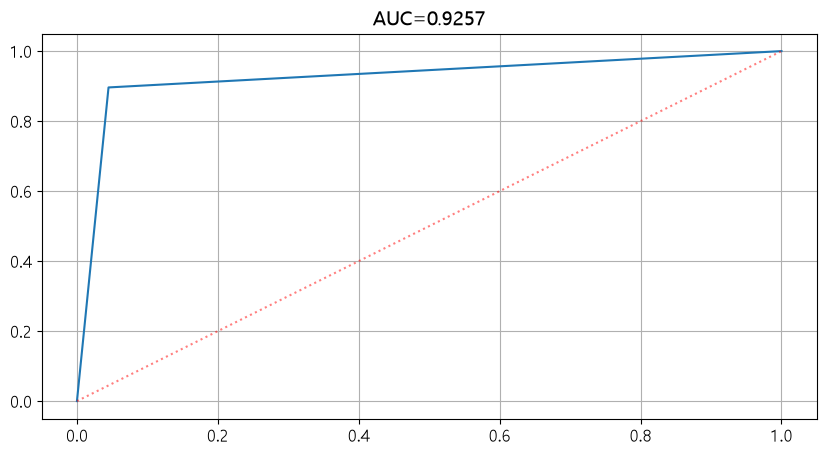

In [13]:
ras = roc_auc_score(df1['악성여부'], df1['예측결과'])
# 위양성율, 재현율, 임계값(사용한함)
fpr, tpr, thresholdes = roc_curve(df1['악성여부'], df1['예측결과'])

plt.figure()
sb.lineplot(x=fpr, y=tpr)
sb.lineplot(x=[0,1], y=[0,1], color='red', linestyle=':', alpha=0.5)
plt.title('AUC={:.4f}'.format(ras))
plt.grid()
plt.show()
plt.close()

In [14]:
# 정확도
acc = accuracy_score(df1['악성여부'], df1['예측결과'])

# 정밀도
pre = precision_score(df1['악성여부'], df1['예측결과'])

# 재현율
recall = recall_score(df1['악성여부'], df1['예측결과'])

# F1 score
f1 = f1_score(df1['악성여부'], df1['예측결과'])

# 위양성율
fallout = fp / (fp + tn)

# 특이성
spe = 1- fallout

result_df = DataFrame({'설명력(Pseudo-Rsqe)': [fit.prsquared], '정확도(Accuracy)':[acc], '정밀도(Precision)':[pre], '재현율(Recall, TPR)':[recall], '위양성율(Fallout, FPR)': [fallout], '특이성(Specificity, TNR)':[spe], 'RAS': [ras], 'f1_score':[f1]})

result_df

,설명력(Pseudo-Rsqe),정확도(Accuracy),정밀도(Precision),"재현율(Recall, TPR)","위양성율(Fallout, FPR)","특이성(Specificity, TNR)",RAS,f1_score
0,0.750758,0.933216,0.92233,0.896226,0.044818,0.955182,0.925704,0.909091


#### 오즈비(Odds Rate) 구하기
##### 계수값들만 추출하기
###### 독립변수의 coef: logit 함수 계수. 해당 독립함수의 오즈에 log를 씌운 값(자연로그)


In [15]:
coef = fit.params
coef

Intercept    -42.019408
평균반지름          1.396992
평균질감           0.380559
평균매끄러움       144.674227
dtype: float64

오즈비 계산
###### 오즈는 어떤 사건이 발생할 확률을 발생하지 않을 확률로 나눈 값이다. 이 분석에서는 악성여부가 종속변수이므로 악성일 확률을 양성일 확률로 나눈 값이다.
$\text{Odds} = \frac{악성일 확률}{양성일 확률}$

계수값에 대해 `np.exp()` 함수를 적용하면 각각의 회귀계수들을 오즈값으로 변환할 수 있다.

> 오즈비가 1보다 크면 해당 변수가 증가할수록 악성 오즈가 증가하고, 1보다 작으면 악성 오즈가 감소한다. 변수마다 측정 단위가 다르므로 오즈비의 크기만으로 영향력을 단순 비교하면 안 된다.

In [16]:
odds_rate = np.exp(coef)
odds_rate
# 각 변수의 측정 단위가 서로 다르므로 오즈비의 크기는 단위와 함께 해석한다.

Intercept    5.639013e-19
평균반지름        4.043022e+00
평균질감         1.463102e+00
평균매끄러움       6.779825e+62
dtype: float64

가상의 데이터를 통한 악성 여부 예측

In [18]:
myinput = input("평균반지름, 평균질감, 평균매끄러움을 콤마(,)로 구분하여 입력하세요.\n예: 17.99,10.38,0.1184")

if not myinput:
    myinput = "17.99,10.38,0.1184"

myinput = myinput.split(',')
mydata = {'평균반지름': float(myinput[0].strip()), '평균질감': float(myinput[1].strip()), '평균매끄러움': float(myinput[2].strip())}
myresult = fit.predict(mydata)
myresult

0    1.0
dtype: float64

In [ ]:
"입력한 종양이 악성일 확률은 {0:0.2f}%입니다.".format(myresult[0]*100)

'입력한 종양이 악성일 확률은 0.00%입니다.'

이후 진행할 과정

- 로지스틱 회귀 모듈화
- 데이터 표준화 적용 후 결과 비교
- 다른 종양 특성 변수를 추가한 후 결과 비교
- 데이터 표준화 전후의 회귀계수와 성능 비교